In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
#optional (if doesn't work, just upload directly into colab session)
!pip install -q kaggle

from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d mrgeislinger/bart-ridership
!unzip -o bart-ridership.zip

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mrgeislinger/bart-ridership
License(s): Attribution 4.0 International (CC BY 4.0)
100% 394M/394M [00:04<00:00, 89.7MB/s]

Archive:  bart-ridership.zip
  inflating: README.txt              
  inflating: ridership/date-hour-soo-dest-2011.csv  
  inflating: ridership/date-hour-soo-dest-2012.csv  
  inflating: ridership/date-hour-soo-dest-2013.csv  
  inflating: ridership/date-hour-soo-dest-2014.csv  
  inflating: ridership/date-hour-soo-dest-2015.csv  
  inflating: ridership/date-hour-soo-dest-2016.csv  
  inflating: ridership/date-hour-soo-dest-2017.csv  
  inflating: ridership/date-hour-soo-dest-2018.csv  
  inflating: ridership/date-hour-soo-dest-2019.csv  
  inflating: ridership/date-hour-soo-dest-2020.csv  
  inflating: ridership/date-hour-soo-dest-2021.csv  
  inflating: ridership/date-hour-soo-dest-2022.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
df_2019 = pd.read_csv('ridership/date-hour-soo-dest-2019.csv')
df_2019['Era'] = 'Pre-COVID (2019)'

df_2022 = pd.read_csv('ridership/date-hour-soo-dest-2022.csv')
df_2022['Era'] = 'Post-COVID (2022)'

df = pd.concat([df_2019, df_2022], ignore_index=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = pd.Categorical(df['Date'].dt.day_name(), categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

df_2019.groupby('Origin Station')['Trip Count'].sum().sort_values(ascending=False).head(4)

,Trip Count
Origin Station,
MONT,11452725
EMBR,11375886
POWL,9255130
CIVC,7127371


In [ ]:
top_stations =['EMBR', 'MONT', 'POWL', 'CIVC']
df_top = df[df['Origin Station'].isin(top_stations)].copy()

df_grouped = df_top.groupby(['Date', 'Hour', 'Origin Station', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

era_palette = {'Pre-COVID (2019)': '#4C72B0', 'Post-COVID (2022)': '#DD8452'}

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


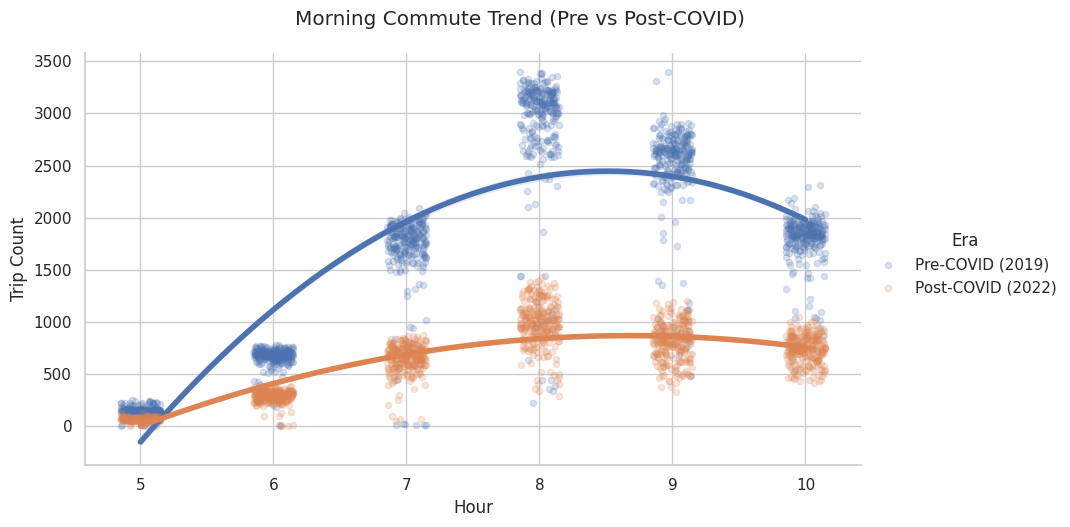

In [ ]:
morning = df_top.groupby(['Date', 'Hour', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

morning = morning[(morning['Hour'] >= 5) & (morning['Hour'] <= 10) & (~morning['Day'].isin(['Saturday', 'Sunday']))]

sns.set_theme(style="whitegrid")
lm = sns.lmplot(
    data=morning,
    x="Hour",
    y="Trip Count",
    hue="Era",
    order=2,
    palette=era_palette,
    x_jitter=0.15,
    scatter_kws={'alpha': 0.2, 's': 20},
    line_kws={'linewidth': 4},
    height=5,
    aspect=1.8,
    legend_out=True
)
lm.fig.suptitle("Morning Commute Trend (Pre vs Post-COVID)", y=1.05)
plt.show()

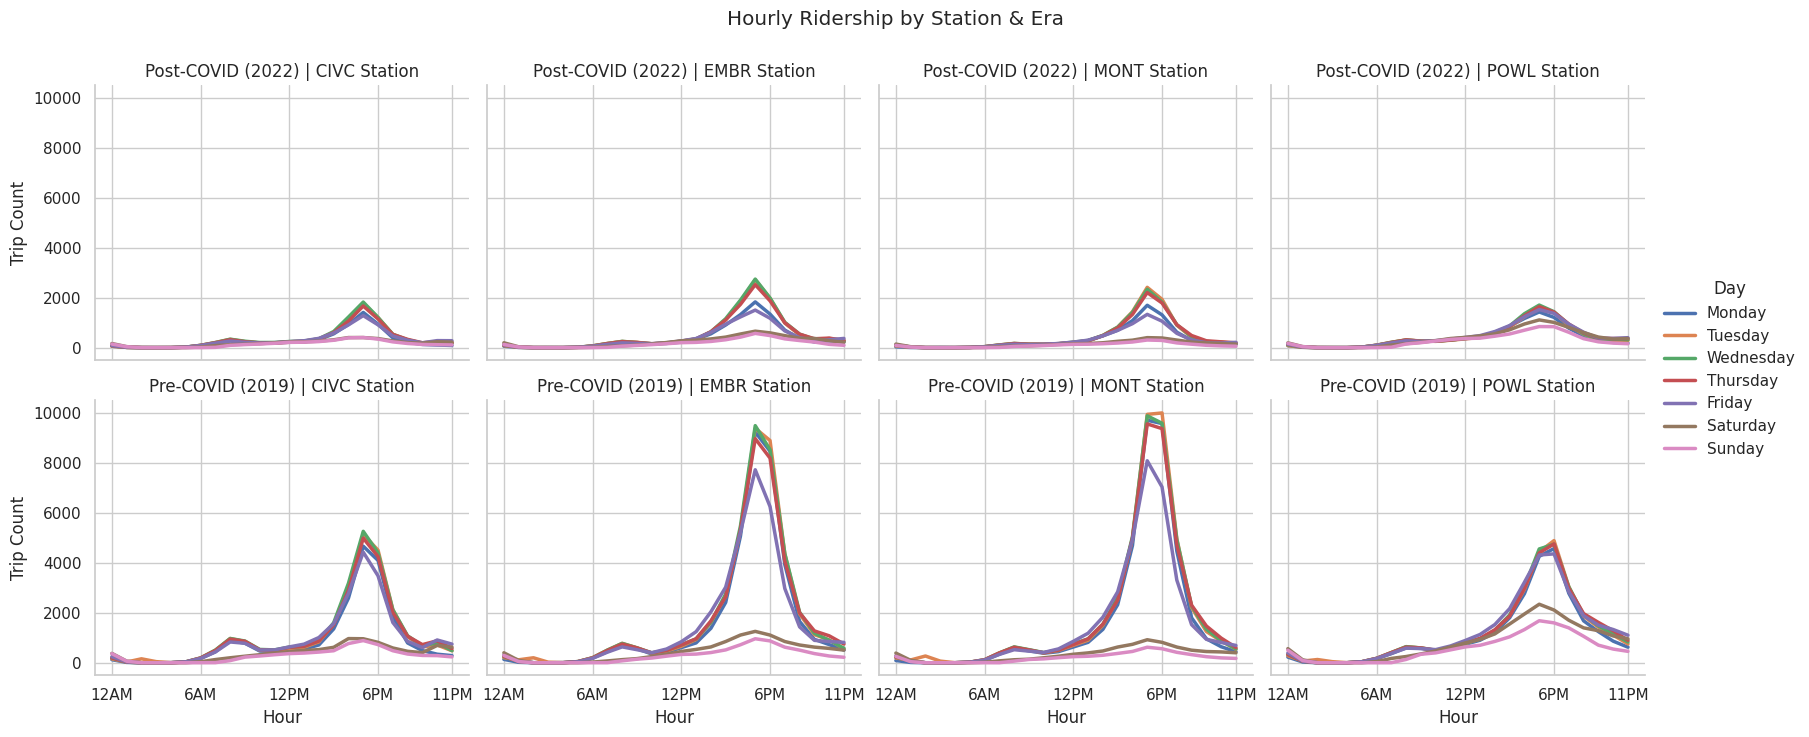

In [ ]:
hourly_avg = df_grouped.groupby(['Hour', 'Origin Station', 'Day', 'Era'], observed=True)['Trip Count'].mean().reset_index()

rel = sns.relplot(
    data=hourly_avg,
    x="Hour", y="Trip Count",
    hue="Day",
    col="Origin Station", row="Era",
    kind="line",
    height=3.5, aspect=1.2,
    linewidth=2.5,
    facet_kws={'sharey': True}
)
rel.set_titles("{row_name} | {col_name} Station")
rel.fig.suptitle("Hourly Ridership by Station & Era", y=1.05)
for ax in rel.axes.flat:
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['12AM', '6AM', '12PM', '6PM', '11PM'])
plt.show()

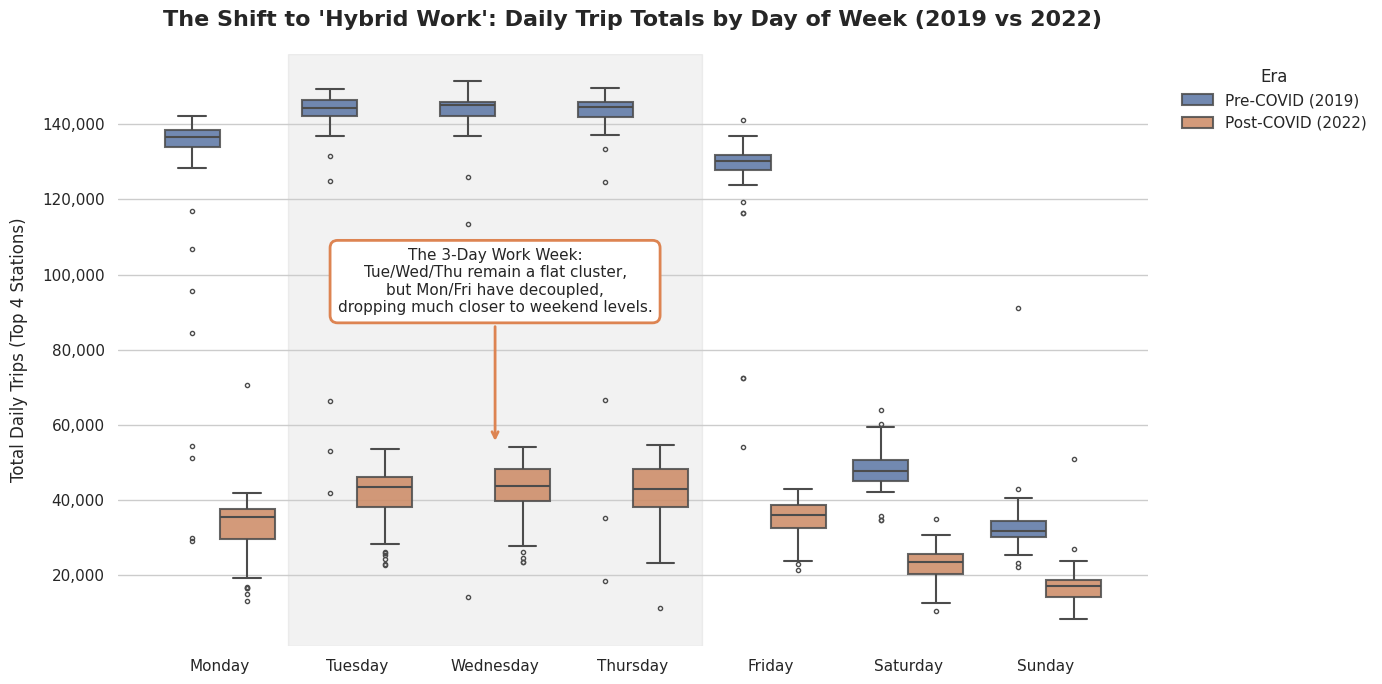

In [ ]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
daily_totals = df_top.groupby(['Date', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

ax = sns.boxplot(
    data=daily_totals,
    x="Day",
    y="Trip Count",
    hue="Era",
    palette=era_palette,
    fliersize=3,
    linewidth=1.5,
    boxprops=dict(alpha=0.85)
)

ax.set_title("The Shift to 'Hybrid Work': Daily Trip Totals by Day of Week (2019 vs 2022)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Total Daily Trips (Top 4 Stations)", fontsize=12, labelpad=10)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

ax.axvspan(0.5, 3.5, color='gray', alpha=0.1, zorder=0)

ax.annotate(
    "The 3-Day Work Week:\nTue/Wed/Thu remain a flat cluster,\nbut Mon/Fri have decoupled,\ndropping much closer to weekend levels.",
    xy=(2, 55000),
    xytext=(2, 90000),
    ha='center',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#DD8452", lw=2),
    arrowprops=dict(arrowstyle="->", color="#DD8452", lw=2)
)

plt.legend(title='Era', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.xticks(rotation=0, fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [ ]:
import zipfile
import os

!wget "https://www.bart.gov/sites/default/files/2025-12/BART-Stations-tracks-entrances-121025.kmz_.zip"

kmz_path = "BART-Stations-tracks-entrances-121025.kmz_.zip"
extract_path = "kmz_extracted"

with zipfile.ZipFile(kmz_path, 'r') as z:
    z.extractall(extract_path)

kml_file = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".kml"):
            kml_file = os.path.join(root, file)

print(kml_file)

--2026-05-05 02:54:27--  https://www.bart.gov/sites/default/files/2025-12/BART-Stations-tracks-entrances-121025.kmz_.zip
Resolving www.bart.gov (www.bart.gov)... 104.18.30.20, 104.18.31.20, 2606:4700::6812:1e14, ...
Connecting to www.bart.gov (www.bart.gov)|104.18.30.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84824 (83K) [application/zip]
Saving to: ‘BART-Stations-tracks-entrances-121025.kmz_.zip’

BART-Stations-track 100%[===================>]  82.84K  --.-KB/s    in 0.006s  

2026-05-05 02:54:27 (12.5 MB/s) - ‘BART-Stations-tracks-entrances-121025.kmz_.zip’ saved [84824/84824]

kmz_extracted/doc.kml


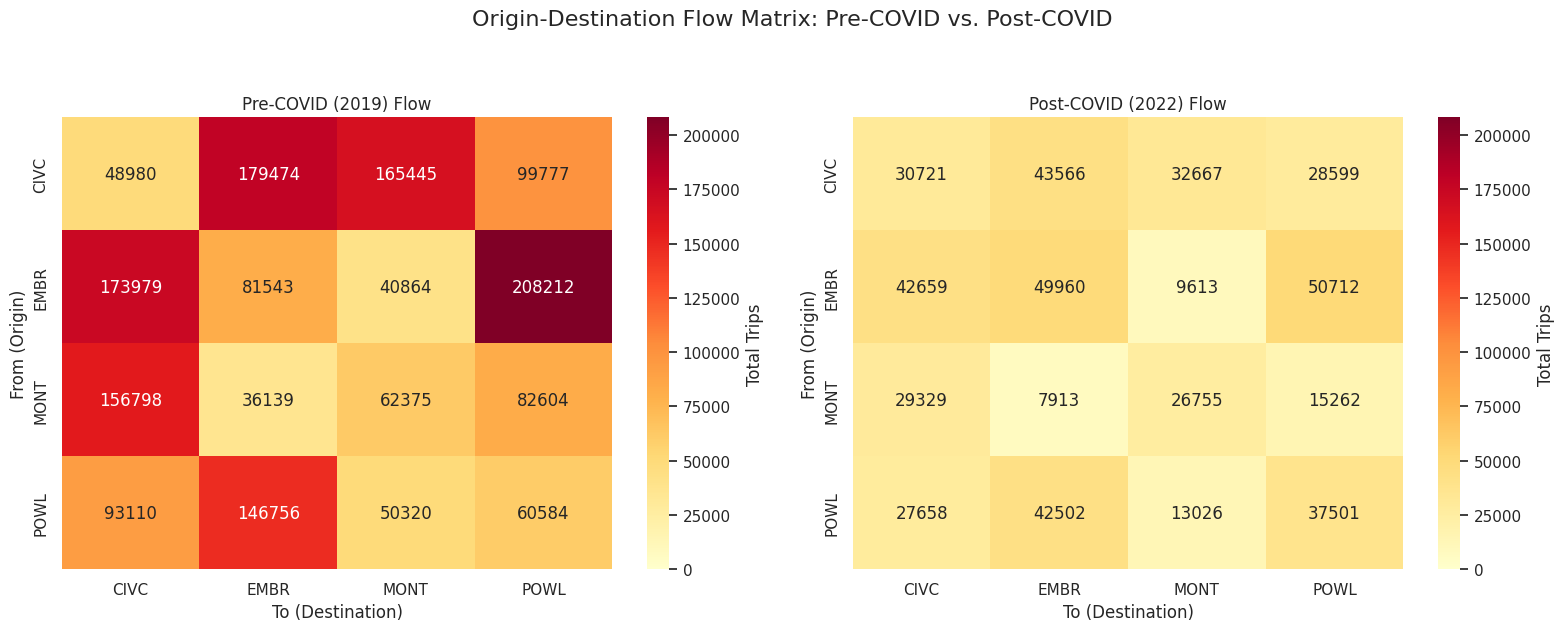

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

od_df = df[df['Origin Station'].isin(top_stations) & df['Destination Station'].isin(top_stations)].copy()

od_grouped = od_df.groupby(['Origin Station', 'Destination Station', 'Era'], observed=True)['Trip Count'].sum().reset_index()

global_max = od_grouped['Trip Count'].max()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Origin-Destination Flow Matrix: Pre-COVID vs. Post-COVID', fontsize=16, y=1.05)

eras =['Pre-COVID (2019)', 'Post-COVID (2022)']

for i, era in enumerate(eras):
    era_data = od_grouped[od_grouped['Era'] == era]

    pivot_matrix = era_data.pivot(index='Origin Station', columns='Destination Station', values='Trip Count')

    sns.heatmap(pivot_matrix, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[i],
                vmin=0, vmax=global_max, cbar_kws={'label': 'Total Trips'})

    axes[i].set_title(f"{era} Flow")
    axes[i].set_ylabel("From (Origin)")
    axes[i].set_xlabel("To (Destination)")

plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
import fiona

fiona.drvsupport.supported_drivers['KML'] = 'rw'
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'

print(f"Reading KML layers from: {kml_file}")

kml_layers = fiona.listlayers(kml_file)
print("Layers found in KML:", kml_layers)

barts_geodata = {}
for layer in kml_layers:
    try:
        barts_geodata[layer] = gpd.read_file(kml_file, driver='KML', layer=layer)
        print(f"Successfully loaded layer: {layer}")
    except Exception as e:
        print(f"Could not load {layer}: {e}")

Reading KML layers from: kmz_extracted/doc.kml
Layers found in KML: ['Station Entrance', 'BART Station', 'BART Track Centerline']
Successfully loaded layer: Station Entrance
Successfully loaded layer: BART Station
Successfully loaded layer: BART Track Centerline


In [ ]:
extracted_coords = {}

for layer_name, gdf in barts_geodata.items():

    if 'station' in layer_name.lower() and 'line' not in layer_name.lower():
        print(f"Extracting coordinates from layer: {layer_name}")

        for idx, row in gdf.iterrows():
            station_name = row.get('Name', f'Station_{idx}')

            centroid = row.geometry.centroid

            extracted_coords[station_name] =[round(centroid.y, 4), round(centroid.x, 4)]

print("\nAutomatically Extracted Coordinates from KML:")
for name, coords in extracted_coords.items():
    print(f"'{name}': {coords},")

Extracting coordinates from layer: Station Entrance
Extracting coordinates from layer: BART Station

Automatically Extracted Coordinates from KML:
'B2 13th St and Broadway Entrance / Exit': [37.8033, -122.2717],
'Elevator Entrance / Exit': [37.7797, -122.4137],
'Adeline Street East Entrance / Exit Elevator': [37.8528, -122.2696],
'A2 John F Foran Fwy (Ramp) Entrance / Exit': [37.722, -122.4475],
'East Entrance / Exit': [37.7215, -122.1604],
'West Entrance / Exit to Parking Garage': [37.6845, -122.4664],
'Elevated Walkway to Amtrak Station, Coliseum Arena Entrance / Exit': [37.754, -122.1974],
'West Concourse Entrance / Exit': [37.6641, -122.4441],
'A John Daly, Junipero Serra Blvd Entrance / Exit': [37.7061, -122.469],
'Main Entrance / Exit': [37.3685, -121.8746],
'East Plaza Entrance / Exit': [37.5575, -121.9764],
'A Entrance / Exit': [37.8935, -122.1247],
'North Entrance / Exit': [37.3687, -121.8747],
'B 19th Street / Civic Center Entrance / Exit': [37.9368, -122.353],
'West Entrance

In [ ]:
from textwrap import fill
import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display, clear_output
import folium
import matplotlib.pyplot as plt
import seaborn as sns

station_coords = {
    '12TH':[37.8036, -122.2717], '16TH':[37.7651, -122.4197], '19TH':[37.8085, -122.2687],
    '24TH':[37.7522, -122.4185], 'ANTC':[37.9954, -121.7804], 'ASHB':[37.8526, -122.27],
    'BALB':[37.7214, -122.4476], 'BAYF':[37.6969, -122.1265], 'BERY':[37.3685, -121.8747],
    'CAST':[37.6907, -122.0756], 'CIVC':[37.7794, -122.4139], 'COLM':[37.6846, -122.4662],
    'COLS':[37.7537, -122.1969], 'CONC':[37.9738, -122.0291], 'DALY':[37.7063, -122.4689],
    'DBRK':[37.8703, -122.2682], 'DELN':[37.9252, -122.3169], 'DUBL':[37.7017, -121.8991],
    'EMBR':[37.7929, -122.3969], 'FRMT':[37.5575, -121.9766], 'FTVL':[37.7749, -122.2242],
    'GLEN':[37.7331, -122.4338], 'HAYW':[37.6697, -122.087],  'LAFY':[37.8932, -122.1246],
    'LAKE':[37.7973, -122.2652], 'MCAR':[37.8291, -122.2671], 'MLBR':[37.6002, -122.3869],
    'MLPT':[37.4103, -121.8911], 'MONT':[37.7894, -122.4012], 'NBRK':[37.874, -122.2834],
    'NCON':[38.0033, -122.0246], 'OAKL':[37.713, -122.2124],  'ORIN':[37.8784, -122.1838],
    'PCTR':[38.0169, -121.8895], 'PHIL':[37.9284, -122.056],  'PITT':[38.0189, -121.944],
    'PLZA':[37.9026, -122.2989], 'POWL':[37.7849, -122.407],  'RICH':[37.9367, -122.3531],
    'ROCK':[37.8447, -122.2513], 'SANL':[37.7218, -122.1608], 'SBRN':[37.6377, -122.4163],
    'SFIA':[37.616, -122.3924],  'SHAY':[37.6344, -122.0572], 'SSAN':[37.6642, -122.444],
    'UCTY':[37.5907, -122.0173], 'WARM':[37.5023, -121.9394], 'WCRK':[37.9058, -122.0673],
    'WDUB':[37.6998, -121.9281], 'WOAK':[37.8049, -122.2952]
}

df_grouped_all = df.groupby(['Date', 'Hour', 'Origin Station', 'Era'], observed=True)['Trip Count'].sum().reset_index()

era_dropdown = widgets.Dropdown(
    options=['Pre-COVID (2019)', 'Post-COVID (2022)'],
    value='Pre-COVID (2019)',
    description='Select Era:',
    style={'description_width': 'initial'}
)

station_dropdown = widgets.Dropdown(
    options=sorted(list(station_coords.keys())),
    value='EMBR',
    description='Select Station:',
    style={'description_width': 'initial'}
)

map_output = widgets.Output(layout=Layout(width='50%', height='550px', border='1px solid #ddd'))
plot_output = widgets.Output(layout=Layout(width='50%', height='550px', border='1px solid #ddd'))

def update_dashboard(change=None):
    era_val = era_dropdown.value
    station_val = station_dropdown.value

    with map_output:
        clear_output(wait=True)

        f = folium.Figure(height=530)

        m = folium.Map(
            location=station_coords[station_val],
            zoom_start=15,
            tiles="CartoDB positron"
        ).add_to(f)

        for layer_name, gdf in barts_geodata.items():
            if 'line' in layer_name.lower() or 'track' in layer_name.lower():
                style = {'color': '#0099cc', 'weight': 4, 'opacity': 0.5}
            else:
                style = {'color': 'gray', 'weight': 1, 'fillOpacity': 0.2}

            folium.GeoJson(
                gdf.to_json(),
                name=layer_name,
                style_function=lambda x, style=style: style
            ).add_to(m)

        pin_color = "darkblue" if '2019' in era_val else "orange"
        folium.Marker(
            location=station_coords[station_val],
            popup=f"<b>{station_val} Station</b><br>{era_val} Selected",
            icon=folium.Icon(color=pin_color, icon="info-sign"),
            tooltip=f"Currently Viewing: {station_val}"
        ).add_to(m)

        display(f)

    with plot_output:
        clear_output(wait=True)

        filtered_df = df_grouped_all[(df_grouped_all['Era'] == era_val) & (df_grouped_all['Origin Station'] == station_val)]
        hourly_stats = filtered_df.groupby('Hour', observed=True)['Trip Count'].mean().reset_index()

        plt.figure(figsize=(7, 5.5))

        plot_color = '#4C72B0' if '2019' in era_val else '#DD8452'
        sns.barplot(data=hourly_stats, x='Hour', y='Trip Count', color=plot_color)

        station_all_eras = df_grouped_all[df_grouped_all['Origin Station'] == station_val]

        max_val = station_all_eras.groupby(['Era', 'Hour'], observed=True)['Trip Count'].mean().max()
        if max_val > 0:
            plt.ylim(0, max_val * 1.1)

        plt.title(f"Average Hourly Ridership\n{station_val} Station | {era_val}", fontsize=14, fontweight='bold')
        plt.xlabel("Hour of the Day (0-23)", fontsize=12)
        plt.ylabel("Average Trip Count", fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

era_dropdown.observe(update_dashboard, names='value')
station_dropdown.observe(update_dashboard, names='value')

ui = widgets.HBox([station_dropdown, era_dropdown], layout=Layout(margin='0 0 20px 0'))
dashboard_view = widgets.VBox([
    ui,
    widgets.HBox([map_output, plot_output])
])

display(widgets.HTML("<h2 style='text-align:center;'>BART Ridership Interactive Executive Dashboard</h2>"))
display(dashboard_view)

update_dashboard()

HTML(value="<h2 style='text-align:center;'>BART Ridership Interactive Executive Dashboard</h2>")